# Modelo 1 — Segmentación de Clientes (RFM) con K-Means

**Ingeniería de variables:**
- R = Recencia invertida (`Days_Since_Last_Purchase`)
- F = `Total_Purchases × 0.65 + Login_Frequency × 0.35`
- M = `Average_Order_Value × 0.40 + Lifetime_Value × 0.60`

**Criterios de éxito:**
- Silhouette Score > 0.45
- Codo claro en WCSS
- Todos los segmentos > 5% de la base

## 1. Setup y paths

In [1]:
import sys
import os

# Agrega la raíz del proyecto al path para importar DataCleaner
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_PATH   = '../data-base/ecommerce_customer_churn_dataset.csv'
MODELS_DIR  = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 2. Librerías

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
import importlib.util as _ilu
_spec = _ilu.spec_from_file_location('data_cleaning',
    os.path.join(PROJECT_ROOT,'src','dataMining','data_cleaning.py'))
_m = _ilu.module_from_spec(_spec); _spec.loader.exec_module(_m)
DataCleaner = _m.DataCleaner

## 3. Carga y limpieza de datos

In [3]:
cleaner = DataCleaner(
    input_path=DATA_PATH,
    output_path=None,          # No guardar CSV limpio desde el notebook
    max_age=100,
    min_purchases=1,
    max_cart_rate=100.0,
    iqr_multiplier=1.5,
    impute_strategy='mean',
)
df = cleaner.run()
print(f'Dataset limpio: {df.shape[0]:,} registros | {df.shape[1]} columnas')
df.head()

[LOAD] 50,000 registros cargados desde '../data-base/ecommerce_customer_churn_dataset.csv'
[QUALITY] Edad > 100 eliminados → quedan 47,485 (removed 2,515)
[QUALITY] Duplicados eliminados → quedan 47,485 (removed 0)
[OUTLIERS] Sin compras eliminados → quedan 47,440 (removed 45)
[OUTLIERS] Cart abandonment > 100.0 eliminados → quedan 47,412 (removed 28)
[OUTLIERS] AOV outliers (IQR ×1.5) eliminados → quedan 46,467 (removed 945)
[IMPUTE] Sin nulos restantes ✓
Dataset limpio: 46,467 registros | 25 columnas


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.000000,50.6,3.0,...,17.9,9.0,4.0,16.300000,20.8,1.000000,953.33,2278.0,0.0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.300000,37.7,1.0,...,42.8,7.0,3.0,29.400403,23.3,3.000000,1067.47,3028.0,0.0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.600000,70.9,1.0,...,0.0,4.0,1.0,29.400403,8.8,2.356643,1289.75,2317.0,0.0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.800000,41.7,9.0,...,41.4,2.0,5.0,85.900000,31.0,3.000000,2340.92,2674.0,0.0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.747072,19.1,9.0,...,37.9,1.0,11.0,83.000000,50.4,4.000000,3041.29,5354.0,0.0,Q4


## 4. Ingeniería de variables RFM

In [4]:
FEATURES = ['Days_Since_Last_Purchase', 'Total_Purchases', 'Login_Frequency',
            'Average_Order_Value', 'Lifetime_Value']

work_df = df.copy()
MAX_RECENCY = work_df['Days_Since_Last_Purchase'].max()

work_df['R_Score'] = MAX_RECENCY - work_df['Days_Since_Last_Purchase']
work_df['F_Score'] = work_df['Total_Purchases'] * 0.65 + work_df['Login_Frequency'] * 0.35
work_df['M_Score'] = work_df['Average_Order_Value'] * 0.40 + work_df['Lifetime_Value'] * 0.60

rfm_cols = ['R_Score', 'F_Score', 'M_Score']
print(work_df[rfm_cols].describe().round(2))

        R_Score   F_Score   M_Score
count  46467.00  46467.00  46467.00
mean     257.20     12.61    891.12
std       28.76      6.56    523.94
min        0.00      0.65     47.14
25%      248.00      7.80    508.55
50%      264.00     11.74    781.54
75%      278.00     16.45   1156.33
max      287.00     89.11   4326.59


## 5. Selección automática de K — Método del Codo + Silhouette

  K | n_init | max_iter | Silhouette |         WCSS
----------------------------------------------------


  2 |     10 |      300 |     0.3951 |        884.9


  3 |     10 |      300 |     0.4064 |        640.1


  4 |     30 |      300 |     0.3339 |        504.1


  5 |     20 |      300 |     0.3149 |        444.9


  6 |     10 |      300 |     0.2799 |        391.6


  7 |     20 |      300 |     0.2842 |        353.8


  8 |     20 |      300 |     0.2756 |        327.9


  9 |     10 |      300 |     0.2582 |        303.1


 10 |     10 |      300 |     0.2646 |        281.2

K óptimo → 3 | Silhouette: 0.4064 | Params: {'n_init': 10, 'max_iter': 300, 'algorithm': 'lloyd'}


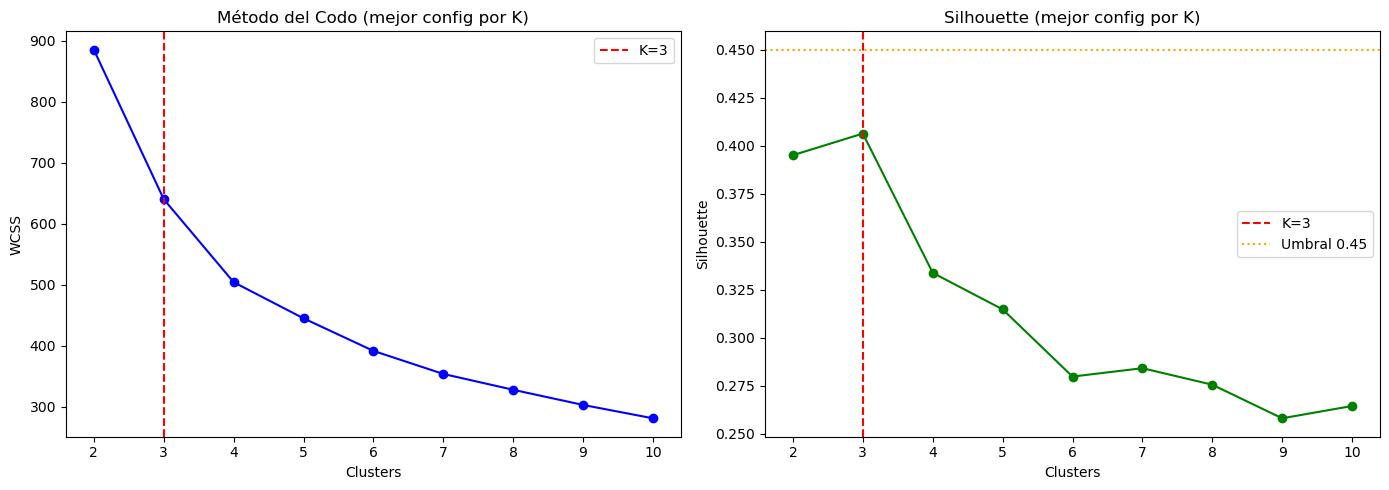

In [5]:
scaler   = MinMaxScaler()
x_scaled = scaler.fit_transform(work_df[rfm_cols])

# ── Grid search sobre hiperparámetros de K-Means ────────────────────────
# silhouette_score con sample_size para datos grandes (O(N²) -> O(S²))
SIL_SAMPLE = min(5_000, len(x_scaled))
K_RANGE    = range(2, 11)
N_INITS    = [10, 20, 30]
MAX_ITERS  = [300, 500]

best_params_per_k: dict = {}
wcss_list, sil_list = [], []

print(f'{"K":>3} | {"n_init":>6} | {"max_iter":>8} | {"Silhouette":>10} | {"WCSS":>12}')
print('-' * 52)

for k in K_RANGE:
    best_sil, best_wcss, best_combo = -1.0, float('inf'), {}
    for n_init, max_iter in product(N_INITS, MAX_ITERS):
        km = KMeans(n_clusters=k, n_init=n_init, max_iter=max_iter,
                    algorithm='lloyd', random_state=42)
        labels = km.fit_predict(x_scaled)
        sil = silhouette_score(x_scaled, labels,
                               sample_size=SIL_SAMPLE, random_state=42)
        if sil > best_sil:
            best_sil, best_wcss = sil, km.inertia_
            best_combo = dict(n_init=n_init, max_iter=max_iter, algorithm='lloyd')
    best_params_per_k[k] = {'silhouette': best_sil, 'wcss': best_wcss, 'params': best_combo}
    wcss_list.append(best_wcss)
    sil_list.append(best_sil)
    p = best_combo
    print(f'{k:>3} | {p["n_init"]:>6} | {p["max_iter"]:>8} | {best_sil:>10.4f} | {best_wcss:>12.1f}')

# ── Selección de K óptimo ────────────────────────────────────────────────
second_diff = np.diff(np.diff(np.array(wcss_list)))
elbow_k     = int(list(K_RANGE)[int(np.argmax(second_diff)) + 1])
elbow_sil   = sil_list[elbow_k - 2]
max_sil_k   = int(list(K_RANGE)[int(np.argmax(sil_list))])
OPTIMAL_K   = elbow_k if elbow_sil >= 0.35 else max_sil_k
BEST_PARAMS = best_params_per_k[OPTIMAL_K]['params']
print(f'\nK óptimo → {OPTIMAL_K} | Silhouette: {sil_list[OPTIMAL_K-2]:.4f} | Params: {BEST_PARAMS}')

# ── Visualización ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_RANGE), wcss_list, 'b-o')
axes[0].axvline(OPTIMAL_K, color='red', linestyle='--', label=f'K={OPTIMAL_K}')
axes[0].set_title('Método del Codo (mejor config por K)')
axes[0].set_xlabel('Clusters'); axes[0].set_ylabel('WCSS'); axes[0].legend()
axes[1].plot(list(K_RANGE), sil_list, 'g-o')
axes[1].axvline(OPTIMAL_K, color='red', linestyle='--', label=f'K={OPTIMAL_K}')
axes[1].axhline(0.45, color='orange', linestyle=':', label='Umbral 0.45')
axes[1].set_title('Silhouette (mejor config por K)')
axes[1].set_xlabel('Clusters'); axes[1].set_ylabel('Silhouette'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Entrenamiento del modelo final

In [6]:
kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    n_init=BEST_PARAMS['n_init'],
    max_iter=BEST_PARAMS['max_iter'],
    algorithm=BEST_PARAMS['algorithm'],
    random_state=42,
)
work_df['RFM_Cluster'] = kmeans.fit_predict(x_scaled)
SIL_SAMPLE = min(5_000, len(x_scaled))
final_sil = silhouette_score(x_scaled, work_df['RFM_Cluster'],
                               sample_size=SIL_SAMPLE, random_state=42)
print(f'Silhouette Score final: {final_sil:.4f}  {"✓ CUMPLE" if final_sil > 0.45 else "⚠ Por debajo de 0.45"}')
print(f'Hiperparámetros: K={OPTIMAL_K} | n_init={BEST_PARAMS["n_init"]} | '
      f'max_iter={BEST_PARAMS["max_iter"]} | algorithm={BEST_PARAMS["algorithm"]}')

Silhouette Score final: 0.4064  ⚠ Por debajo de 0.45
Hiperparámetros: K=3 | n_init=10 | max_iter=300 | algorithm=lloyd


## 7. Nomenclatura de segmentos

In [7]:
centroid_scores = (
    kmeans.cluster_centers_[:, 0] * 0.30
    + kmeans.cluster_centers_[:, 1] * 0.40
    + kmeans.cluster_centers_[:, 2] * 0.30
)
sorted_clusters = np.argsort(centroid_scores)[::-1]
base_labels = ['Champions', 'Clientes Leales', 'Potenciales', 'En Riesgo', 'Perdidos/Inactivos']
labels_pool = (
    base_labels[:OPTIMAL_K]
    if OPTIMAL_K <= 5
    else [f'Segmento {i+1}' for i in range(OPTIMAL_K)]
)
SEGMENT_NAMES = {
    int(cid): labels_pool[rank]
    for rank, cid in enumerate(sorted_clusters)
}
work_df['RFM_Segment'] = work_df['RFM_Cluster'].map(SEGMENT_NAMES)

print('Mapa de segmentos:', SEGMENT_NAMES)

seg_dist = (work_df['RFM_Segment'].value_counts(normalize=True) * 100).round(2)
print('\nDistribución:')
for seg, pct in seg_dist.items():
    print(f'  {"✓" if pct > 5.0 else "⚠"}  {seg:<25} {pct:.1f}%')

Mapa de segmentos: {0: 'Champions', 1: 'Clientes Leales', 2: 'Potenciales'}

Distribución:
  ✓  Clientes Leales           59.6%
  ✓  Champions                 27.1%
  ✓  Potenciales               13.2%


## 8. Visualización de segmentos

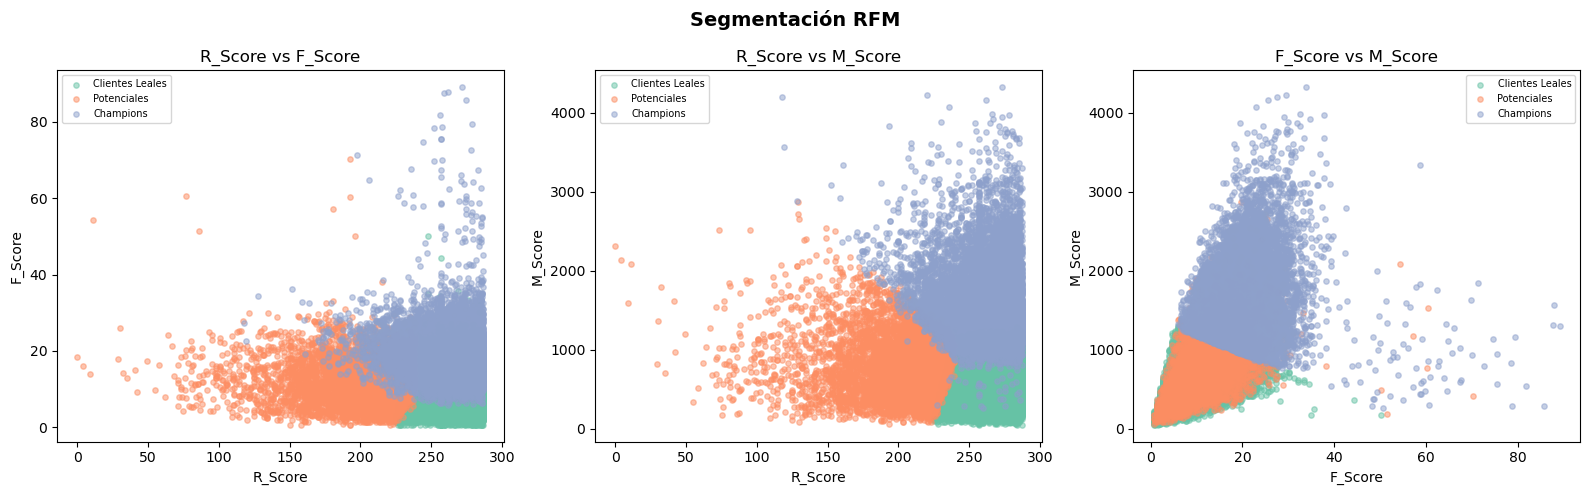

,Recencia,Frecuencia,Monetario,Clientes
RFM_Segment,,,,
Champions,23.63,19.75,2481.44,12598
Clientes Leales,20.17,10.29,957.35,27718
Potenciales,85.81,12.38,1236.18,6151


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [('R_Score', 'F_Score'), ('R_Score', 'M_Score'), ('F_Score', 'M_Score')]
segments = work_df['RFM_Segment'].unique()
palette  = sns.color_palette('Set2', len(segments))
color_map = dict(zip(segments, palette))

for ax, (xcol, ycol) in zip(axes, pairs):
    for seg in segments:
        mask = work_df['RFM_Segment'] == seg
        ax.scatter(work_df.loc[mask, xcol], work_df.loc[mask, ycol],
                   c=[color_map[seg]], label=seg, alpha=0.5, s=15)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f'{xcol} vs {ycol}')
    ax.legend(fontsize=7)

plt.suptitle('Segmentación RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de perfiles
profiles = work_df.groupby('RFM_Segment').agg(
    Recencia=('Days_Since_Last_Purchase', 'mean'),
    Frecuencia=('Total_Purchases', 'mean'),
    Monetario=('Lifetime_Value', 'mean'),
    Clientes=('RFM_Segment', 'count'),
).round(2)
display(profiles)

## 9. Exportar modelo

Exporta el modelo entrenado, el scaler y metadatos a `../models/rfm_model.pkl`.

In [9]:
rfm_bundle = {
    'model':          kmeans,
    'scaler':         scaler,
    'segment_names':  SEGMENT_NAMES,
    'max_recency':    MAX_RECENCY,
    'rfm_cols':       rfm_cols,
    'input_features': FEATURES,
    'optimal_k':      OPTIMAL_K,
    'silhouette':     round(final_sil, 4),
    'best_params':    BEST_PARAMS,
}
out_path = os.path.join(MODELS_DIR, 'rfm_model.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(rfm_bundle, f)
print(f'Modelo RFM exportado -> {out_path}')
print(f'  K={OPTIMAL_K} | Silhouette={final_sil:.4f} | Best params: {BEST_PARAMS}')
print(f'  Segmentos: {list(SEGMENT_NAMES.values())}')

Modelo RFM exportado -> ../models/rfm_model.pkl
  K=3 | Silhouette=0.4064 | Best params: {'n_init': 10, 'max_iter': 300, 'algorithm': 'lloyd'}
  Segmentos: ['Champions', 'Clientes Leales', 'Potenciales']
